In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
</style>
"""))

**<font size="6" color="red">ch2. 한글형태소 분석 및 시각화</font>**
# 1. 자연어처리
- 자연어 : 일상적인 언어
- 자연어 처리 분야
    * 탐색(이해) : 형태소 분석 -> pos tagging(품사태깅) -> 의미분석 또는 시각화
    * 모델 생성 : RNN, LSTM, GRU, seq2seq, transformer
    
# 2. 자연어 처리 절차
- 분석 후보 생성 : 형태소 분리, 품사태깅
- 제약조건 : 규칙 확인 및 불용어 처리
- 분석 : 시각화(워드클라우드, plot), 유사도 분석, 연관분석, RNN, LSTM, GRU, seq2seq, transformer

# 3. 한글 형태소 분석 엔진(Konlpy, ...)
    - 공통기능 : morphs(형태소 나누기), pos(형태소로 나누어 품사태그), nouns(명사추출)

- Konlpy (pip install konlpy) : Konlpy.org -> API -> KoNLPy로 품사 태깅하기에서 다운로드
    * HanNanum : 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수, path설정)
    * Kkma     : 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수, path설정)
    * Komoran  : 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수, path설정)
    * Okt(Twitter)
- Mecab(pip install python-mecab-ko)
    * MeCab : C++로 만든 형태소 분석기. 저사양환경에서 사용가능. 다국어바인딩 지원
- Konlp : R용 자연어 처리기

In [2]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [3]:
import konlpy
konlpy.__version__

'0.6.0'

## 3.1 HanNanum

In [9]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''

In [10]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None,
                   max_heap_size=512) # 기본값:1024, '1024m', '1g' 최대사이즈 4g
hannanum.analyze(text) # text를 세밀하게 분석해서, 형태소, 품사를 반환(ntag=69로 형태소 분석)

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('기', 'etn'), ('도', 'jxc')]],
 [[('하', 'pvg'), ('ㄴ', 'etm')],
  [('한', 'nnc')],
  [('한', 'ncn')],
  [('한', 'nbn')],
  [('하', 'px'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [],
 [[('많', 'paa'), ('이', 'xsa')], [('많이', 'mag')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]]]

- Korean POS tags comparison chart.xlsx 다운로드 : Konlpy.org -> API -> KoNLPy로 품사 태깅하기에서 다운로드

In [11]:
# 형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [12]:
# 명사만 추출 : nouns
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [14]:
# 품사 태깅 : pos
print(hannanum.pos(text, ntags=22))

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('기', 'ET'), ('도', 'JX'), ('하', 'PV'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF')]


In [20]:
# ex1. text에서 형용사(PA)만 추출
tagged_text = hannanum.pos(text, ntags=22)
# words = []
# for token, tag in tagged_text:
#     if tag == 'PA':
#         words.append(token)
words = [token for token, tag in tagged_text if tag=='PA']
print(words)

['아름답', '많']


In [24]:
# ex2. text에서 명사(NC, NQ, NP, NN)만 추출
tags = ['NC', 'NQ', 'NP', 'NN']
words = [token for token, tag in tagged_text if tag in tags]
words

['복잡', '한국어', '전세계', '13', '사용', '언어']

In [25]:
# ex3. text에서 보통명사(NC)만 추출
tags = ['NC']
words = [token for token, tag in tagged_text if tag in tags]
words

['복잡', '한국어', '전세계', '사용', '언어']

## 3.2 Kkma

In [1]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''

In [2]:
from konlpy.tag import Kkma
# kkma = Kkma(jvmpath=None, max_heap_size=1024)
kkma = Kkma()
# 형태소 분석
print(kkma.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전세계', '에서', '13', '번째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [3]:
# 품사 태깅
print(kkma.pos(text)) # ntags지정 불가(무조건 56으로)

[('아름답', 'VA'), ('지만', 'ECE'), ('다소', 'MAG'), ('복잡', 'NNG'), ('하', 'XSV'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MDN'), ('한국어', 'NNG'), ('는', 'JX'), ('전세계', 'NNG'), ('에서', 'JKM'), ('13', 'NR'), ('번째', 'NNB'), ('로', 'JKM'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETD'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN')]


In [4]:
# 품사태깅을 이용한 명사(NNG, NNP, NP) 추출
tagged_text = kkma.pos(text)
words = [token for token, tag in tagged_text if tag in ('NNG', 'NNP', 'NP')]
print(words)

['복잡', '한국어', '전세계', '사용', '언어']


In [5]:
# nouns함수를 이용한 명사 추출
print(kkma.nouns(text))

['복잡', '한국어', '전세계', '13', '13번째', '번째', '사용', '언어']


## 3.3 Komoran

In [2]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로
많이 사용되는 언어입니다
'''

In [3]:
from konlpy.tag import Komoran
komoran = Komoran()
# 형태소 분석
print(komoran.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [4]:
# 명사 추출
print(komoran.nouns(text))

['한국어', '전', '세계', '번', '사용', '언어']


In [6]:
# 품사태깅(pos tagging)
tagged_list = komoran.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNP'), ('는', 'JX'), ('전', 'NNG'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNB'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EC')]


In [9]:
# 일반명사(NNG) + 고유명사(NNP) 추출
print([token for token, tag in tagged_list if tag in ('NNG', 'NNP')])

['한국어', '전', '세계', '사용', '언어']


## 3.4 Okt (Twitter)
- konlpy v0.4.5부터 Twitter -> Okt로 바뀜
- SNS 텍스트 분석용 개발
- Scala로 개발 -(컴파일)-> .class파일 (JVM위에서 실행)

In [12]:
from konlpy.tag import Twitter, Okt
# okt = Twitter()
okt = Okt()
print('명사구 추출 :', okt.phrases(text))
# 형태소 분석
print('형태소 분석 :', okt.morphs(text))

명사구 추출 : ['다소', '한국어', '전세계', '13번째', '사용', '사용되는 언어', '13', '번째', '언어']
형태소 분석 : ['아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '\n', '많이', '사용', '되는', '언어', '입니다', '\n']


In [13]:
# 명사만 추출
print(okt.nouns(text))

['다소', '한국어', '전세계', '번', '사용', '언어']


In [14]:
# 품사태깅
tagged_list = okt.pos(text)
print(tagged_list)

[('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡하기도', 'Adjective'), ('한', 'Verb'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('\n', 'Foreign'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('\n', 'Foreign')]


In [17]:
# 명사(Noun)만 추출
print([word for word, tag in tagged_list if tag == 'Noun'])

['다소', '한국어', '전세계', '번', '사용', '언어']


## 3.5 MeCab
- pip install python-mecab-ko
- 압도적 속도(Konlpy 대비 5~20배 빠름)
- 낮은 메모리 사용량
- 형태소 분해 정확도 높음. 네이버, 카카오, 라인 등에서도 mecab 계열을 사용한 사례 많음

In [18]:
# 형태소 분석
from mecab import MeCab
mecab = MeCab()
print(mecab.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다']


In [19]:
# 명사 추출
print(mecab.nouns(text))

['한국어', '세계', '번', '사용', '언어']


In [21]:
# 품사 태깅
tagged_list = mecab.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EC')]


In [22]:
# 명사들(NNG, NNP, NP, NR) 추출
print([token for token, tag in tagged_list if tag in ('NNG', 'NNP', 'NP', 'NR')])

['한국어', '세계', '사용', '언어']


# 4. 말뭉치

In [24]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
print(emma[:30])

[Emma by Jane Austen 1816]

VO


In [25]:
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\ez\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [26]:
# 한국어 말뭉치
from konlpy.corpus import kolaw
kolaw_data = kolaw.open('constitution.txt').read()
print('글자수 :', len(kolaw_data))
print('%r' % kolaw_data[:50])

글자수 : 18884
'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임'


# 5. 워드 클라우드
- pip install wordcloud

In [27]:
nouns = ['word1', 'word2', 'word1']
' '.join(nouns)

'word1 word2 word1'

In [32]:
# 영어 말뭉치에서 2글자 이상의 명사 추출(특수문자 제외)하여 워드클라우드 생성
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
ret = RegexpTokenizer('[a-zA-Z0-9]{2,}') # \w{2,}
words = ret.tokenize(emma)
emma_tags = pos_tag(words)
# 명사 추출(NN, NNS, NNP, NNPS)
noun_list = [token for token, tag in emma_tags if tag in ('NN', 'NNS', 'NNP', 'NNPS')]
print('추출된 명사 갯수 :', len(noun_list), ', 단어 종류수:', len(set(noun_list)))
emma_noun = ' '.join(noun_list)
print('워드 클라우드에서 필요한 text :', emma_noun[:200])

추출된 명사 갯수 : 32488 , 단어 종류수: 4012
워드 클라우드에서 필요한 text : Emma Jane Austen VOLUME CHAPTER Emma Woodhouse clever home disposition blessings existence years world daughters indulgent father consequence marriage mistress house period mother remembrance caresses


In [37]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5] # 기본값 [6.4, 4.8]

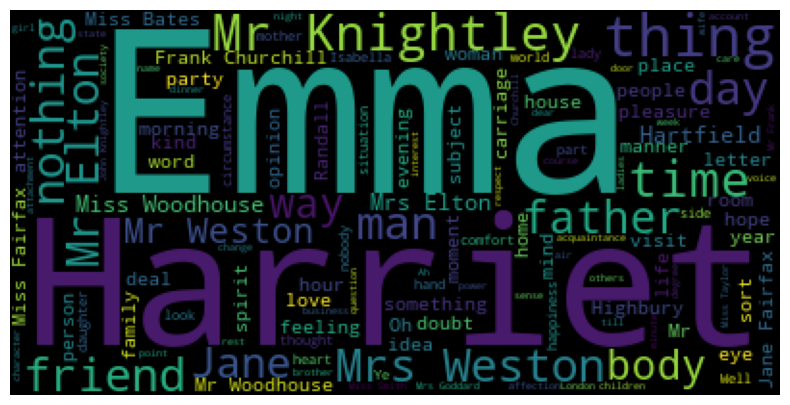

In [40]:
wordcloud = WordCloud()
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

- 컬러맵 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

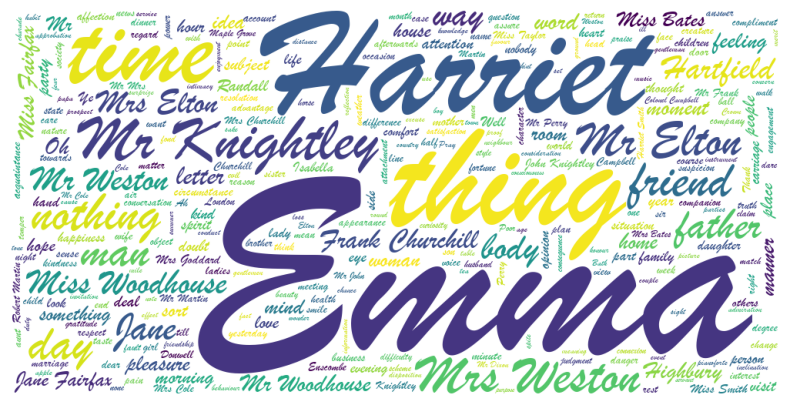

In [54]:
wordcloud = WordCloud(font_path='C:/Windows/Fonts/BRUSHSCI.TTF', # 글자 폰트
                     width=1000, # 생성될 이미지 가로(픽셀) 기본값은 400
                     height=500, # 생성될 이미지 세로(픽셀) 기본값은 200
                     background_color='white' , #배경색
                     max_words=300, #표시될 단어의 최대 갯수
                     relative_scaling=0.9, # 단어 빈도에 따른 크기 차이
                     colormap='viridis', # 글씨 색상들(컬러맵)
                     #max_font_size=80, # 최대 폰트 사이즈(픽셀)
                     #min_font_size=10 #최소 폰트 사이즈
                    )
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [55]:
# 생성된 wordcloud 저장
wordcloud.to_file('emma.jpg') # jpg나 png

In [62]:
# 한글 말뭉치 kolaw_data
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab      import MeCab
from nltk       import FreqDist
import pandas   as pd

analyzer = MeCab()
#noun_list = analyzer.nouns(kolaw_data)
noun_list = [word for word, tag in analyzer.pos(kolaw_data) if tag in ('NNG', 'NNP')]
noun_wordcount = FreqDist(noun_list)
wordCnt = pd.Series(noun_wordcount)
wordCnt.sort_values(ascending=False, inplace=True)
wordCnt.head(10)

법률     121
대통령     84
조       79
국가      73
헌법      69
국민      69
국회      69
때       55
필요      31
위원      30
dtype: int64

In [63]:
# 워드 클라우드에서 필요한 text
data_noun = ' '.join(noun_list)
data_noun[:100]

'대한민국 헌법 역사 전통 국민 운동 건립 대한민국 임시 정부 법통 불의 항거 민주 이념 계승 조국 민주 개혁 평화 통일 사명 입각 정의 인도 동포 애 민족 단결 사회 폐습 불의 타'

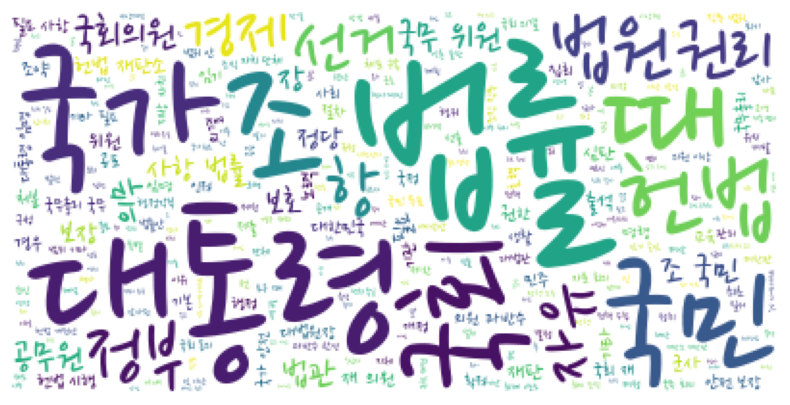

In [65]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white', # 배경색
                max_words=300, #표시될 최대 단어 수
                colormap='viridis',
                # random_state=3
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [67]:
# 불용어 처리
from wordcloud import STOPWORDS # 영어권 등록된 불용어 셋
from nltk.corpus import stopwords
print(stopwords.fi)
불용어 = stopwords.words('english')
print(불용어)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she